#Exercise-**1**

##1. Read and display the image

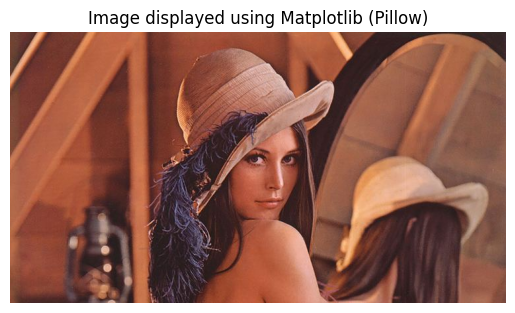

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/Python/Contents/Images/lenna.jpeg'

# 1. Read and display the image using Pillow and Matplotlib
# Read the image using Pillow
img = Image.open(image_path)

# Display the image using Matplotlib
plt.imshow(img)
plt.axis('off')
plt.title('Image displayed using Matplotlib (Pillow)')
plt.show()

##2. Display only the top left corner of 100x100 pixels.

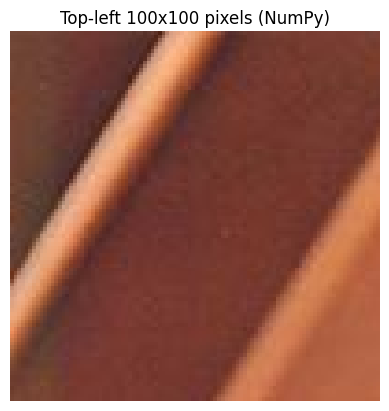

In [23]:
import numpy as np

# Convert the PIL image to a NumPy array
img_np = np.array(img)

# Extract the top-left corner (100x100 pixels) using array indexing
crop_img_np = img_np[0:100, 0:100]

# Display the cropped image
plt.imshow(crop_img_np)
plt.axis('off')
plt.title('Top-left 100x100 pixels (NumPy)')
plt.show()

##3. Show the three color channels (R, G, B).

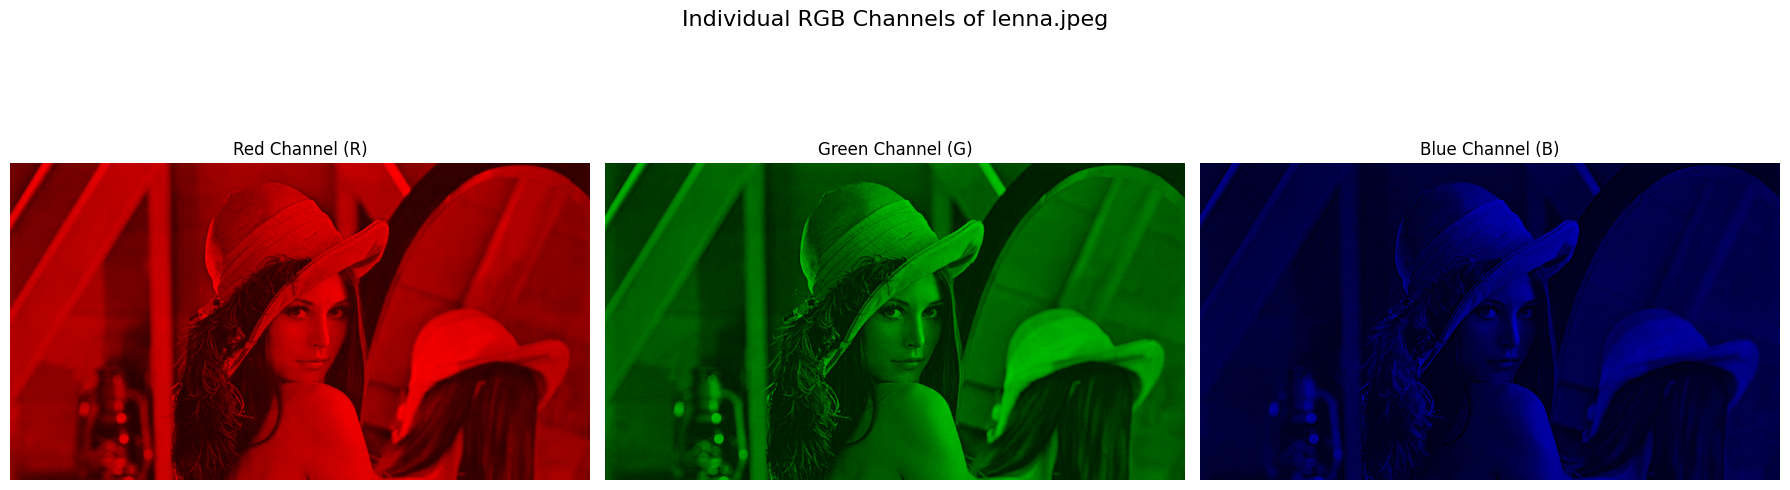

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'img_np' is available from previous cells (e.g., cell JH6s7whfaWzo)
# and contains the NumPy array of 'lenna.jpeg' which is a color image.

# Ensure img_np is a 3-channel (RGB) array
if img_np.ndim == 2: # If it's grayscale, convert it to RGB for channel separation
    img_rgb_np = np.stack([img_np, img_np, img_np], axis=-1)
elif img_np.ndim == 3 and img_np.shape[2] == 3:
    img_rgb_np = img_np
else:
    # Handle other cases if necessary, e.g., RGBA by taking first 3 channels
    img_rgb_np = img_np[:, :, :3]

# Separate the channels using NumPy array indexing
red_channel_data = img_rgb_np[:, :, 0] # Red channel intensity data
green_channel_data = img_rgb_np[:, :, 1] # Green channel intensity data
blue_channel_data = img_rgb_np[:, :, 2] # Blue channel intensity data

# Create 3-channel images where only one channel carries the intensity information
# and others are zero, to visually represent each color component.

# Red Channel Visualization (only red component active)
red_display_img = np.zeros_like(img_rgb_np) # Create a black image of same shape
red_display_img[:, :, 0] = red_channel_data # Assign red intensity to red component

# Green Channel Visualization (only green component active)
green_display_img = np.zeros_like(img_rgb_np)
green_display_img[:, :, 1] = green_channel_data

# Blue Channel Visualization (only blue component active)
blue_display_img = np.zeros_like(img_rgb_np)
blue_display_img[:, :, 2] = blue_channel_data

# Create a figure with 3 subplots to display each channel visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Display the Red Channel Visualization
axes[0].imshow(red_display_img)
axes[0].set_title('Red Channel (R)')
axes[0].axis('off')

# Display the Green Channel Visualization
axes[1].imshow(green_display_img)
axes[1].set_title('Green Channel (G)')
axes[1].axis('off')

# Display the Blue Channel Visualization
axes[2].imshow(blue_display_img)
axes[2].set_title('Blue Channel (B)')
axes[2].axis('off')

plt.suptitle('Individual RGB Channels of lenna.jpeg', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

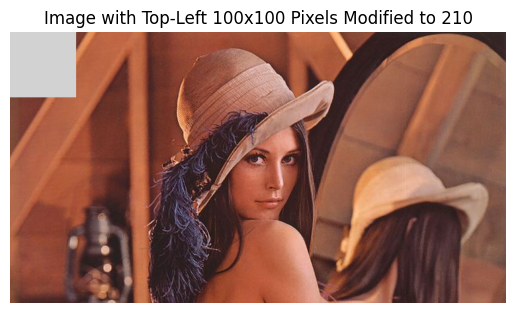

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming img_np contains the original image as a NumPy array
# from previous steps (e.g., cell JH6s7whfaWzo).
# Create a copy to avoid modifying the original image data in place.
modified_img_np = np.copy(img_np)

# Modify the top-left 100x100 pixels to a value of 210
# For grayscale images, 210 represents a light gray.
modified_img_np[0:100, 0:100] = 210

# Display the modified image
plt.imshow(modified_img_np, cmap='gray') # Assuming it's a grayscale image
plt.axis('off')
plt.title('Image with Top-Left 100x100 Pixels Modified to 210')
plt.show()

#Exercise-2

##1. Load and display a grayscale image.

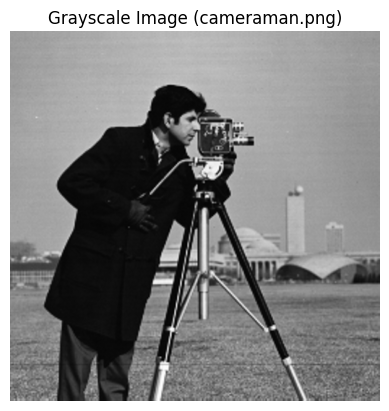

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

grayscale_image_path = '/content/drive/MyDrive/Python/Contents/Images/cameraman.png'

# 1. Load a grayscale image using the Pillow library
# Open the image
img_gray = Image.open(grayscale_image_path)



# 2. Display the grayscale image using matplotlib
plt.imshow(img_gray, cmap='gray') # Use cmap='gray' to ensure it's displayed in shades of gray
plt.axis('off') # Hide axes
plt.title('Grayscale Image (cameraman.png)')
plt.show()

##2. Extract and display the middle section of the image (150 pixels).

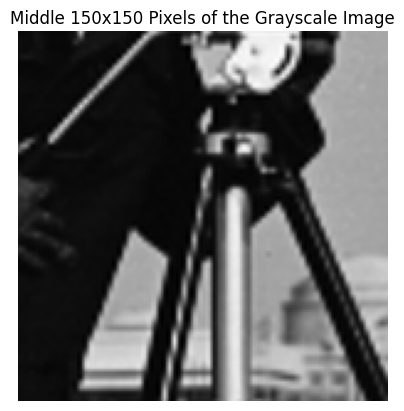

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Convert the PIL image to a NumPy array
img_np_gray = np.array(img_gray)

# Get image dimensions
height, width = img_np_gray.shape

# Define the size of the section to extract
section_size = 150

# Calculate the starting and ending coordinates for the middle section
# Ensure the section is centered as much as possible
start_row = (height - section_size) // 2
end_row = start_row + section_size
start_col = (width - section_size) // 2
end_col = start_col + section_size

# Extract the middle section using NumPy array slicing
middle_section = img_np_gray[start_row:end_row, start_col:end_col]

# Display the cropped image
plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.title(f'Middle {section_size}x{section_size} Pixels of the Grayscale Image')
plt.show()

##3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

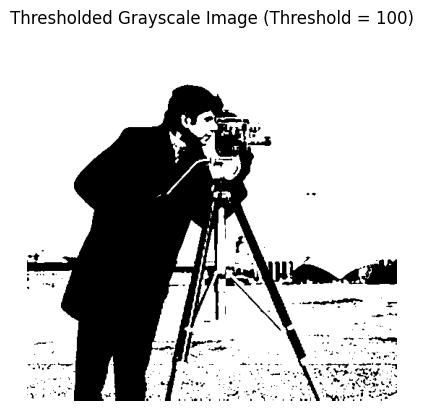

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Create a copy to avoid modifying the original image data in place.
thresholded_img = np.copy(img_np_gray)

# Apply the threshold
# Set all pixel values below 100 to 0
thresholded_img[thresholded_img < 100] = 0

# Set all pixel values above 100 to 255
thresholded_img[thresholded_img >= 100] = 255

# Display the resulting binary image
plt.imshow(thresholded_img, cmap='gray') # Use cmap='gray' for binary images
plt.axis('off')
plt.title('Thresholded Grayscale Image (Threshold = 100)')
plt.show()

##4. Rotate the image 90 degrees clockwise and display the result.

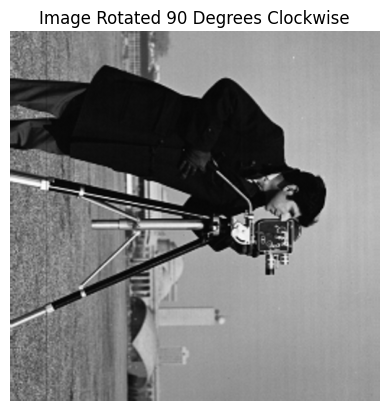

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Rotate the image 90 degrees clockwise
# In Pillow, rotate(angle) rotates counter-clockwise. So, -90 degrees is clockwise.
rotated_img_pil = img_gray.rotate(-90, expand=True) # expand=True adjusts canvas size

# Convert the rotated PIL image to a NumPy array for displaying with matplotlib
rotated_img_np = np.array(rotated_img_pil)

# Display the rotated image
plt.imshow(rotated_img_np, cmap='gray')
plt.axis('off')
plt.title('Image Rotated 90 Degrees Clockwise')
plt.show()

##5. Convert the grayscale image to an RGB image.

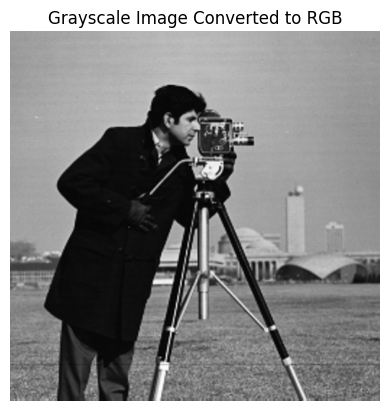

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Convert the PIL grayscale image to a NumPy array
img_np_gray = np.array(img_gray)

# Create an empty RGB image array with the same dimensions as the grayscale image
# and 3 channels, initializing with zeros (black).
# The dtype should match the original image (e.g., uint8).
rgb_image_np = np.zeros((*img_np_gray.shape, 3), dtype=img_np_gray.dtype)

# Replicate the grayscale values across all three channels (R, G, B)
rgb_image_np[:, :, 0] = img_np_gray # Red channel
rgb_image_np[:, :, 1] = img_np_gray # Green channel
rgb_image_np[:, :, 2] = img_np_gray # Blue channel

# Display the converted RGB image using Matplotlib
plt.imshow(rgb_image_np)
plt.axis('off')
plt.title('Grayscale Image Converted to RGB')
plt.show()

#Image Compression and Decompression using PCA.

##1. Load and Prepare Data:

In [31]:

image_path = '/content/drive/MyDrive/Python/Contents/Images/lena_gray.gif'


img = Image.open(image_path)
img_np_gray = np.array(img)

In [32]:
print(f"Shape of the grayscale image (img_np_gray): {img_np_gray.shape}")

Shape of the grayscale image (img_np_gray): (512, 512)


In [33]:
import numpy as np

# Calculate the mean of each column (feature)
mean_per_column = np.mean(img_np_gray, axis=0)

# Subtract the mean from each column to center the data
centered_data = img_np_gray - mean_per_column

print("Shape of centered_data:", centered_data.shape)
print("Mean of centered_data (should be close to zero):")
print(np.mean(centered_data, axis=0))


Shape of centered_data: (512, 512)
Mean of centered_data (should be close to zero):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [34]:
import numpy as np

# Calculate the covariance matrix of the centered data
# rowvar=False means that each column is a variable, and each row is an observation.
covariance_matrix = np.cov(centered_data, rowvar=False)

print("Shape of covariance_matrix:", covariance_matrix.shape)
# Display a portion of the covariance matrix to verify
print("First 5x5 block of covariance_matrix:\n", covariance_matrix[:5, :5])

Shape of covariance_matrix: (512, 512)
First 5x5 block of covariance_matrix:
 [[3209.09099422 3210.23773468  364.23316337  431.32384418  338.66603091]
 [3210.23773468 3211.50947514  365.53095569  431.0183158   340.01384769]
 [ 364.23316337  365.53095569 3622.23388194  516.70385886  756.8099124 ]
 [ 431.32384418  431.0183158   516.70385886 3401.2287182   224.65212206]
 [ 338.66603091  340.01384769  756.8099124   224.65212206 3354.63539246]]


##2. Eigen Decomposition and Identifying Principal Components:

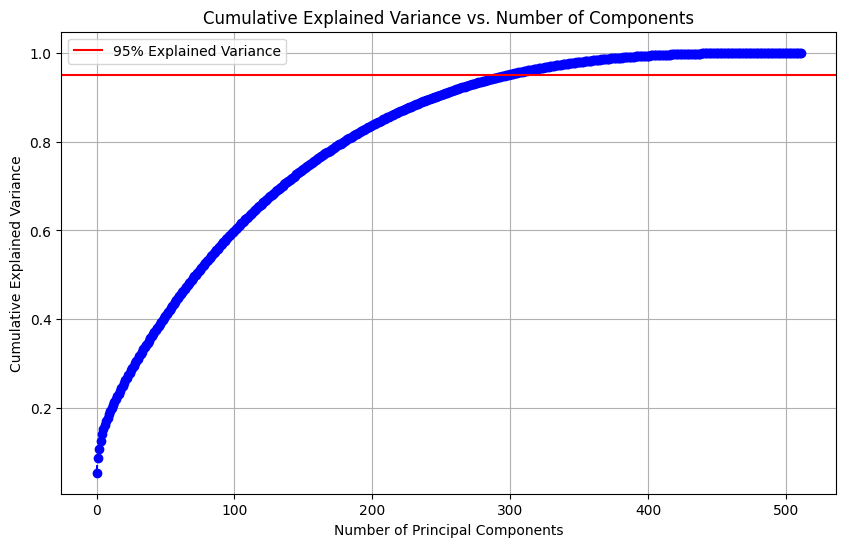

Total Eigenvalues: 512
Number of components to explain 95% variance: 299


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute Eigenvalues and Eigenvectors from the covariance matrix
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

# 2. Sort eigenvalues and eigenvectors in descending order
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# 3. Calculate Explained Variance and Cumulative Explained Variance
sum_eigenvalues = np.sum(sorted_eigenvalue)
explained_variance = sorted_eigenvalue / sum_eigenvalues
cumulative_variance = np.cumsum(explained_variance)

# 4. Identify Principal Components with the help of cumulative Sum plot
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend(loc='best')
plt.show()

# Print some useful info
print(f"Total Eigenvalues: {len(sorted_eigenvalue)}")
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {k_95}")

##3. Reconstruction and Experiment:

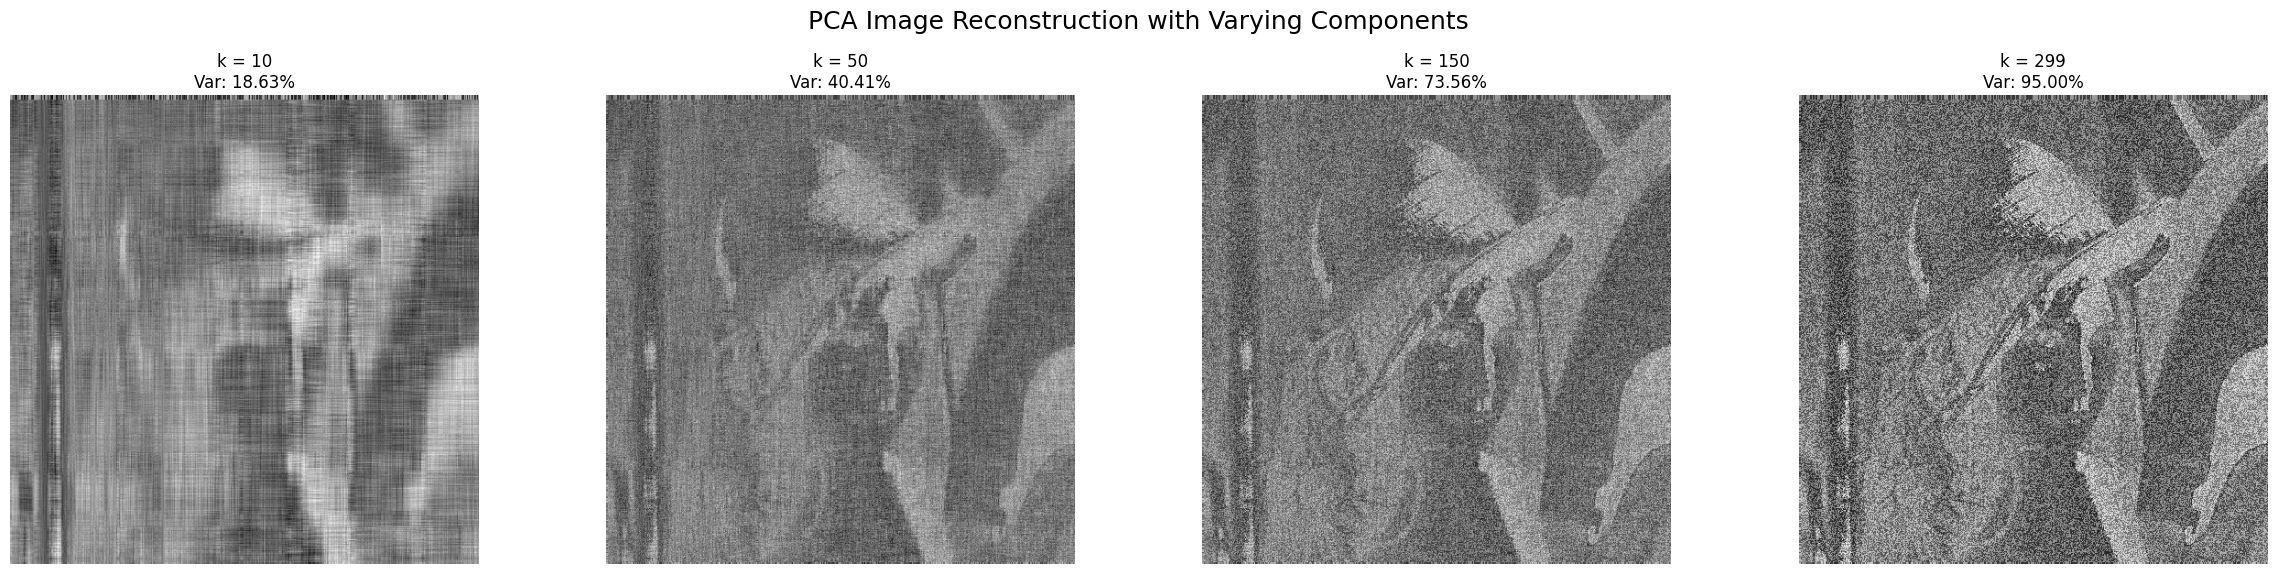

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a list of the chosen number of components
k_values = [10, 50, 150, 299]

# 2. Initialize a matplotlib figure
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# 3. Iterate through each value of k in the list
for i, k in enumerate(k_values):
    # a. Select the top k eigenvectors
    selected_vectors = sorted_eigenvectors[:, :k]

    # b. Project the centered_data into the k-dimensional subspace
    projected_data = np.dot(centered_data, selected_vectors)

    # c. Reconstruct the data back to the original space
    reconstructed_data = np.dot(projected_data, selected_vectors.T)

    # d. Add the mean_per_column back to the reconstructed data
    final_reconstructed_img = reconstructed_data + mean_per_column

    # e. Get cumulative explained variance for the current k
    # k-1 because array is 0-indexed
    variance_explained = cumulative_variance[k-1] * 100

    # f. Display the reconstructed image in the corresponding subplot
    axes[i].imshow(final_reconstructed_img, cmap='gray')
    axes[i].set_title(f'k = {k}\nVar: {variance_explained:.2f}%')
    axes[i].axis('off')

# 4. Adjust the layout and display
plt.suptitle('PCA Image Reconstruction with Varying Components', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Evaluation of PCA Reconstruction

Based on the experiment above, we can evaluate the performance of PCA for image compression:

*   **k = 10 (Var: 18.63%):** The image is highly blurred. Only the coarsest features and lighting patterns are preserved. This represents a very high compression ratio but low fidelity.
*   **k = 50 (Var: 40.41%):** The subject (Lena) is now clearly recognizable, but significant 'ringing' artifacts and loss of texture are visible.
*   **k = 150 (Var: 73.56%):** The image quality is substantially better. Most of the structural details are restored, though some fine-grained noise or sharp edge definition might still be slightly smoothed.
*   **k = 299 (Var: 95.00%):** At this point, the reconstruction is visually almost indistinguishable from the original image. Retaining 95% of the variance is a common target for 'visually lossless' PCA compression.

**Conclusion:** PCA effectively compresses images by keeping only the most significant eigenvectors. We can achieve roughly 50% compression (299 out of 512 components) while maintaining nearly perfect visual quality.